# Example 8: 2-D diffusion-cartogram lite
Run a 2-D cartogram deformation using only the base diffusion-cartogram install —
no geopandas or rasterio required.

Input and output use plain CSV files (`write_csv_2d` / `read_csv_2d`).
This is the 2-D counterpart of Example 5 (3-D lite mode), which used
`write_xyz` / `read_xyz` for point cloud I/O without pymeshlab.

**Requires:** `pip install diffusion-cartogram`  (base install only)

In [1]:
import diffusion_cartogram as vd
import numpy as np

## Step 1: Create boundary points from scratch

We model a stylised city as three concentric zones.  The boundary of each
zone is a circle sampled at 200 points — no geographic file needed.

| Zone | Radius | Density | Interpretation |
|------|--------|---------|----------------|
| Inner | r < 0.8 | ρ = 8 | city centre |
| Middle | 0.8–1.6 | ρ = 3 | suburbs |
| Outer | 1.6–2.4 | ρ = 1 | rural |

After deformation the high-density city centre expands and the low-density
outer zone contracts — making area proportional to population.

Map boundary points: 600


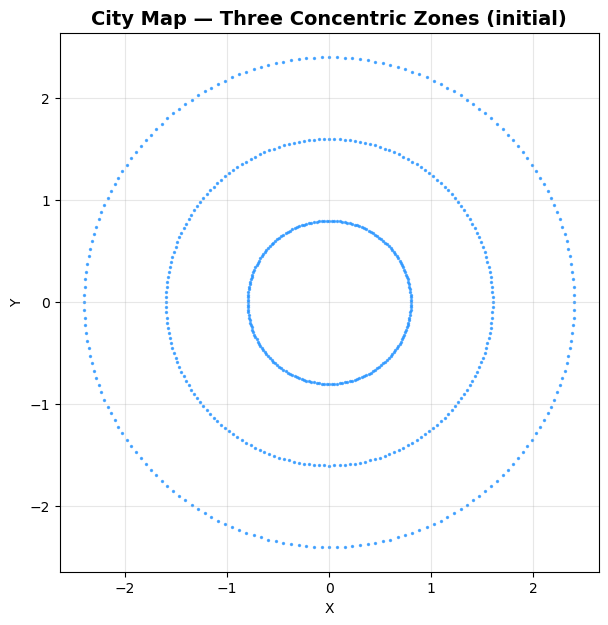

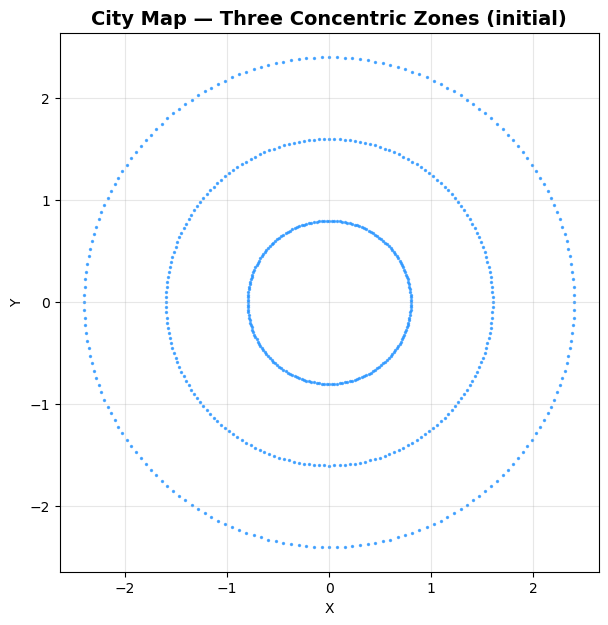

In [2]:
theta = np.linspace(0, 2 * np.pi, 200, endpoint=False)

inner_ring = np.column_stack([0.8 * np.cos(theta), 0.8 * np.sin(theta)])
mid_ring   = np.column_stack([1.6 * np.cos(theta), 1.6 * np.sin(theta)])
outer_ring = np.column_stack([2.4 * np.cos(theta), 2.4 * np.sin(theta)])

map_points = np.vstack([inner_ring, mid_ring, outer_ring])
print(f"Map boundary points: {len(map_points)}")

vd.plot_map_2d(map_points, title='City Map — Three Concentric Zones (initial)')

## Step 2: Save map points to CSV

`write_csv_2d` writes a space-delimited text file.  With no `densities`
argument the file has two columns (`x y`).  Passing `densities` adds a
third column (`x y rho`).

In [3]:
vd.write_csv_2d('city_map.csv', map_points)
print("Saved: city_map.csv  (columns: x  y)")

Saved: city_map.csv  (columns: x  y)


## Step 3: Load from CSV

`read_csv_2d` auto-detects 2-column (`x y`) and 3-column (`x y rho`) files.
It returns `(positions, densities)` where `densities` is `None` if the file
has only two columns.

In [4]:
pts_loaded, rho_loaded = vd.read_csv_2d('city_map.csv')
print(f"Loaded {len(pts_loaded)} points")
print(f"Densities in file: {rho_loaded}  (None = not stored)")

Loaded 600 points
Densities in file: None  (None = not stored)


## Step 4: Create the grid and assign density analytically

We proceed identically to Example 6: `make_initial_grid_2d` sizes the grid
automatically, then `set_density` takes a callable `f(x, y) → float`.

In [5]:
grid_params = vd.make_initial_grid_2d(pts_loaded, max_points=4096)
vd.print_grid_info_2d(grid_params)

2D GRID INFORMATION

Grid dimensions : 64 × 64 = 4,096 points
Grid spacing (h): 0.152381

Grid size  : [9.6000, 9.6000]
Object size: [4.8000, 4.8000]
Ratio      : [2.00x, 2.00x]

Grid bounds:
  x: [-4.8000, 4.8000]
  y: [-4.8000, 4.8000]

Object bounds:
  x: [-2.4000, 2.4000]
  y: [-2.4000, 2.4000]

Object margins:
  x: min=2.4000, max=2.4000
  y: min=2.4000, max=2.4000


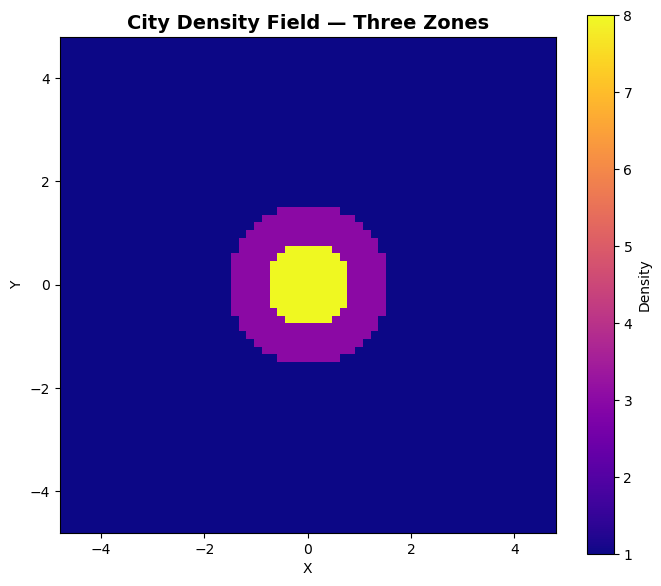

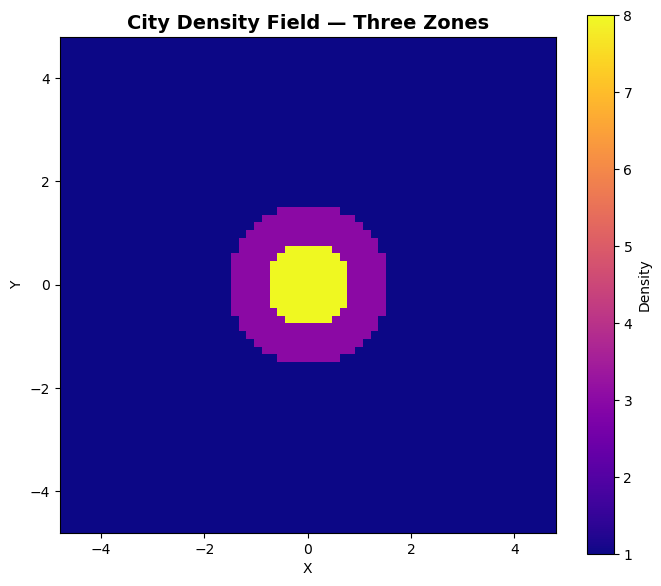

In [6]:
def city_density(x, y):
    """Three-zone concentric population model."""
    r = np.sqrt(x**2 + y**2)
    if r < 0.8:
        return 8.0   # city centre
    elif r < 1.6:
        return 3.0   # suburbs
    else:
        return 1.0   # rural

grid = vd.VDERMGrid2D(
    shape=grid_params['shape'],
    h=grid_params['h'],
    min_bounds=grid_params['min_bounds'],
)
grid.set_density(city_density)

vd.plot_density_field_2d(grid, title='City Density Field — Three Zones')

## Step 5: Run the deformation

No geopandas, rasterio, or pymeshlab involved — only numpy, scipy, and
matplotlib are required for this full 2-D deformation.

In [7]:
deformed_grid = vd.run_VDERM(grid, n_max=500)

Deforming: 100%|██████████| 500/500 [00:01<00:00, 476.76it/s, ε=2.154e-02, target=1.000e-02]


## Step 6: Visualise and export

The deformed outer ring should have moved inward (rural area contracts) while
the inner ring moves outward (city centre expands).

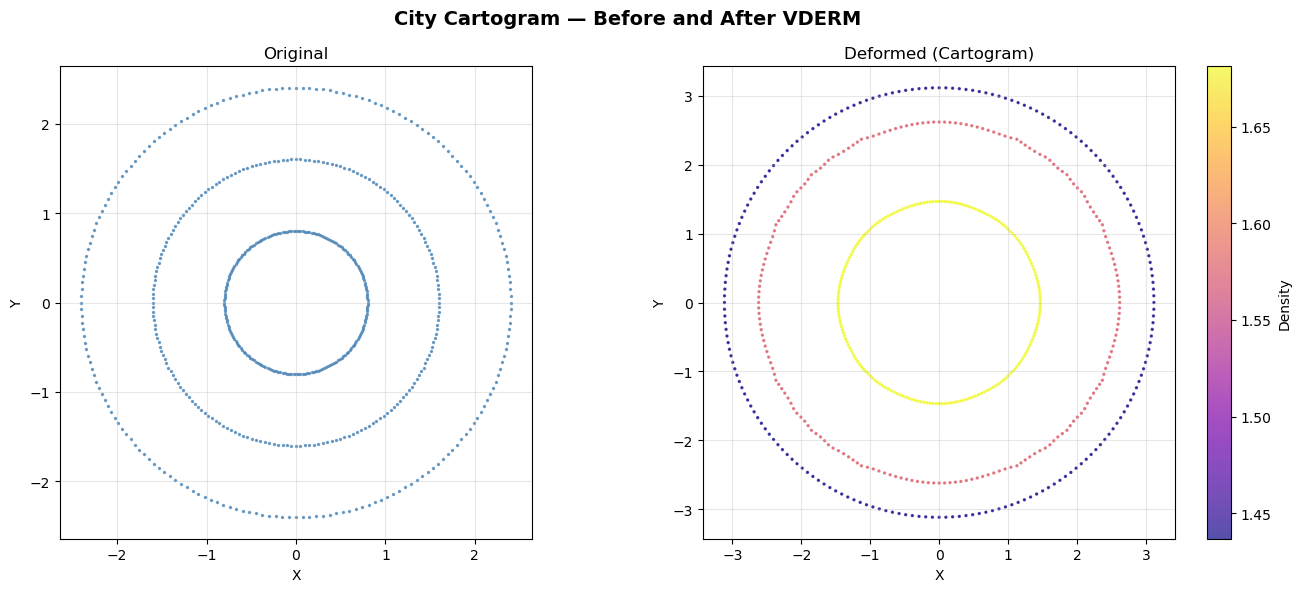

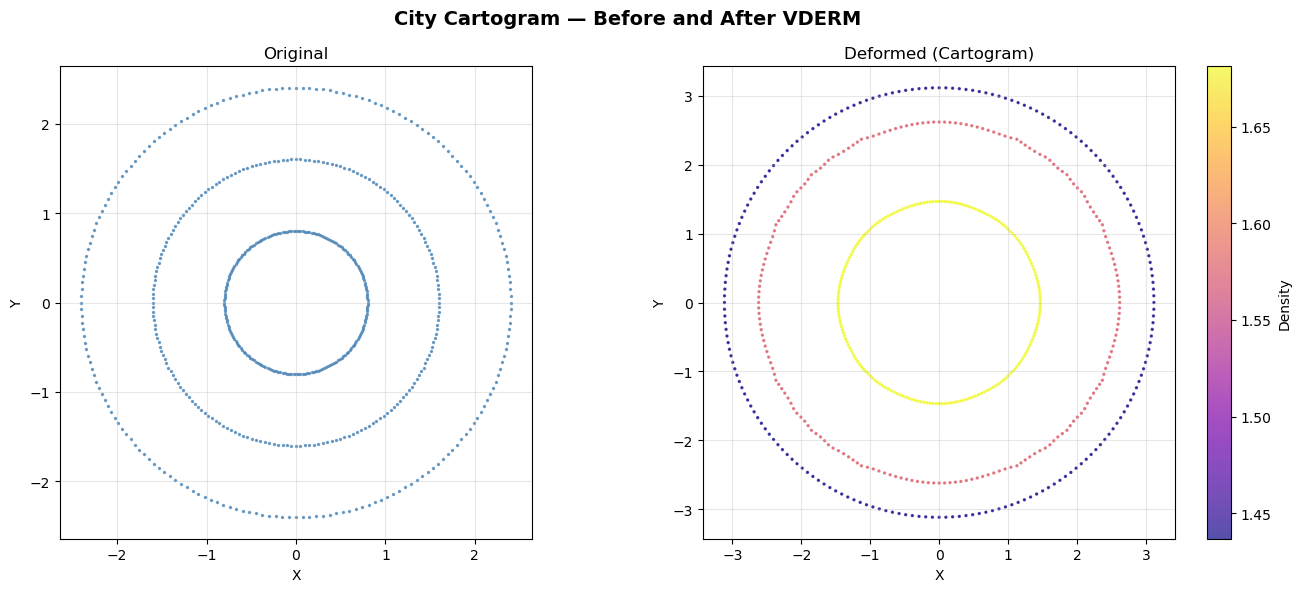

In [8]:
displacement  = deformed_grid.get_displacement_field()
deformed_map  = vd.interpolate_to_map_2d(pts_loaded, grid_params, displacement)
dens_deformed = vd.interpolate_densities_2d(pts_loaded, deformed_grid)

vd.plot_map_before_after(
    pts_loaded, deformed_map,
    densities=dens_deformed,
    title='City Cartogram — Before and After VDERM',
)

In [9]:
vd.write_csv_2d('city_deformed.csv', deformed_map, densities=dens_deformed)
print("Saved: city_deformed.csv  (columns: x  y  rho)")

# Read back to verify
pts_out, rho_out = vd.read_csv_2d('city_deformed.csv')
print(f"Re-loaded {len(pts_out)} points, "
      f"density range [{rho_out.min():.3f}, {rho_out.max():.3f}]")

Saved: city_deformed.csv  (columns: x  y  rho)
Re-loaded 600 points, density range [1.437, 1.681]
